# Credit Card Fraud Detection Model Development

---
embed-resources: true
---

## Introduction

In this report, a credit card fraud detection model is developed to help our bank identify fraudulent transactions in real time. The model is designed to make predictions as soon as a transaction occurs, using available information such as transaction amount and other features. Since fraud cases are rare compared to normal transactions, one of the key challenges was to build a model that can detect fraud accurately without flagging too many legitimate transactions. This report explains the steps how we develop and tune the model, discusses its performance results, and provides a recommendation for its use in our fraud detection system.

## Methods

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    confusion_matrix,
)

# machine learning
from sklearn.tree import DecisionTreeClassifier

# preprocessing imports

from sklearn.model_selection import GridSearchCV

### Data

In [5]:
# load data
fraud_train = pd.read_parquet(
    "https://cs307.org/lab/data/fraud-train.parquet",
)
fraud_test = pd.read_parquet(
    "https://cs307.org/lab/data/fraud-test.parquet",
)

#### Data Dictionary
Each observation in the train, test, and (hidden) production data contains information about a particular credit card transaction.

#### Response

`Fraud`

- `[int64]` status of the transaction. 1 indicates a fraudulent transaction and 0 indicates not fraud, a genuine transaction.

#### Features

`Amount`

- `[float64]` amount (in dollars) of the transaction.

`PC01 - PC28`

- `[float64]` the 28 principal components that encode information such as location and type of purchase while preserving customer privacy.

In [ ]:
# summary statistics
fraud_train[["Fraud","Amount"]].groupby("Fraud").describe()

Amount                                                          
         count        mean         std  min  25%    50%    75%       max
Fraud                                                                   
0      53961.0   88.065104  241.451144  0.0  5.5  21.80  75.97  10199.44
1        315.0  110.947016  254.978960  0.0  1.0   6.99  99.99   2125.87

In [7]:
fraud_train.Amount.describe()

count    54276.000000
mean        88.197903
std        241.535617
min          0.000000
25%          5.490000
50%         21.690000
75%         76.000000
max      10199.440000
Name: Amount, dtype: float64

On average, fraudulent transactions have a higher mean amount (110.95) compared to non-fraudulent ones (88.07), suggesting that fraud may often involve slightly larger transactions. However, interestingly, the median amount for fraudulent transactions is much lower (6.99) than that of non-fraudulent transactions (21.8), indicating that many fraudulent transactions are actually on the lower end in terms of value, and a few large transactions are likely skewing the mean upward.

The maximum amount in fraud cases (2,125.87) is significantly lower than the maximum amount in non-fraud cases (10,199.44), possibly indicating that extremely high-value transactions are more common in legitimate activity or that such transactions are more closely monitored and protected. These insights suggest that while high-value fraud exists, many fraudulent transactions may be small and easily overlooked, highlighting the need for fraud detection systems to account for both large and small anomalies.

In [25]:
# exploratory visualization
a=pd.concat([fraud_train['Fraud'].value_counts(),(fraud_train['Fraud'].value_counts()/fraud_train['Fraud'].count())],axis=1)
a.columns=['Count','Percentage']
a

,Count,Percentage
Fraud,,
0,53961,0.994196
1,315,0.005804


<Figure size 1000x500 with 0 Axes>

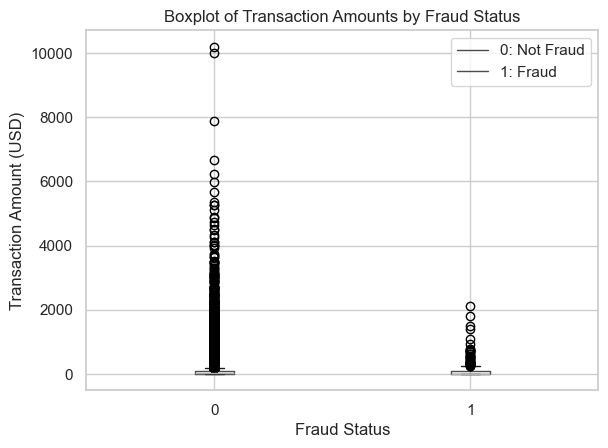

In [36]:
# exploratory visualization
plt.figure(figsize=(10, 5))
boxplot = fraud_train.boxplot(column=['Amount'], by='Fraud')
plt.title('Boxplot of Transaction Amounts by Fraud Status')
plt.suptitle('')  # Remove the automatic 'Boxplot grouped by Fraud' title
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount (USD)')
plt.legend(['0: Not Fraud', '1: Fraud'])
plt.show()

The fraud is only 0.17% of the total data. We can see that there is huge class imbalance in the target variable. We will have to take care of this while building the model. We cam see that the maximum amount in fraud cases is significantly lower than the maximum amount in non-fraud cases, possibly indicating that extremely high-value transactions are more common in legitimate activity or that such transactions are more closely monitored and protected. These insights suggest that while high-value fraud exists, many fraudulent transactions may be small and easily overlooked, highlighting the need for fraud detection systems to account for both large and small anomalies.

### Models

In [11]:
# process data for ML
def print_metric_scores(grid, metric):
    cv_results = grid.cv_results_
    best_index = grid.best_index_
    mean_score = cv_results[f"mean_test_{metric}"][best_index]
    std_score = cv_results[f"std_test_{metric}"][best_index]
    print(f"CV {metric} (mean ± std): {mean_score:.3f} ± {std_score:.3f}")

# create X and y for train
X_train = fraud_train.drop("Fraud", axis=1)
y_train = fraud_train["Fraud"]

# create X and y for test
X_test = fraud_test.drop("Fraud", axis=1)
y_test = fraud_test["Fraud"]

In [12]:
# train models
dt=DecisionTreeClassifier()
# weights for helping with imbalance
weights_list = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.8},
    {0: 1, 1: 2 },
    {0: 1, 1: 2.3},
    "balanced",
]

# define scoring metrics
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(fbeta_score, beta=1),
}

# define parameter grid
rf_param_grid = {
    "max_depth": [2, 3, 4],
    "class_weight": weights_list,
}

# setup grid search
rf_grid = GridSearchCV(
    dt,
    rf_param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
)

# fit model specified by grid search
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print_metric_scores(rf_grid, "recall")
print_metric_scores(rf_grid, "precision")

Best parameters: {'class_weight': {0: 1, 1: 2.3}, 'max_depth': 3}
CV recall (mean ± std): 0.813 ± 0.044
CV precision (mean ± std): 0.910 ± 0.048


The training results show the optimal cross-validation performance for the Decision Tree Classifier using grid search. The best model was identified with a max_depth of 3 and a class weight configuration of {0: 1, 1: 2.3}, indicating a strategic emphasis on the minority (fraudulent) class to address class imbalance. This model achieved a cross-validated recall score of approximately 0.813, meaning it successfully identified over 81% of fraudulent transactions on average. At the same time, the model yielded a precision score of approximately 0.910, indicating that 91% of the transactions predicted as fraud were actually fraudulent. These results suggest that the model is both sensitive to detecting fraud and highly accurate in its predictions, striking a strong balance between minimizing false negatives and reducing false positives. As a result, this Decision Tree model is selected due to its optimal trade-off between fraud detection and prediction reliability.

## Results

In [13]:
# report model metrics
print(recall_score(y_test,rf_grid.predict(X_test)),
precision_score(y_test,rf_grid.predict(X_test)))

0.8227848101265823 0.9285714285714286


After evaluating the best model on the test set, the Decision Tree Classifier achieved a recall score of approximately 0.823, meaning it was able to correctly identify about 82.3% of actual fraud cases. Additionally, it produced a precision score of approximately 0.929, indicating that 92.9% of the transactions predicted as fraudulent were indeed fraud. 

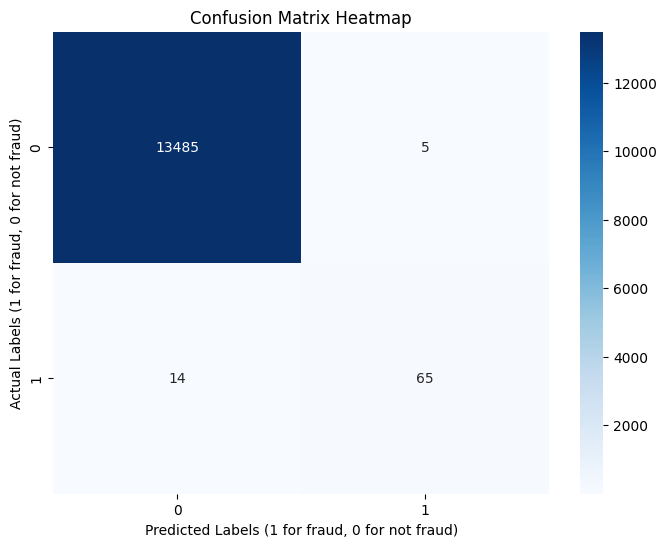

In [14]:
# summary figure
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, rf_grid.predict(X_test))

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_grid.classes_, yticklabels=rf_grid.classes_)

# Labels and title
plt.xlabel("Predicted Labels (1 for fraud, 0 for not fraud)")
plt.ylabel("Actual Labels (1 for fraud, 0 for not fraud)")
plt.title("Confusion Matrix Heatmap")
plt.show()

The confusion matrix provides a detailed breakdown of the model's classification performance on the test data. The top-left value (13,485) represents the number of true negatives, or non-fraudulent transactions that were correctly identified. The bottom-right value (65) indicates the number of true positives, or correctly predicted fraud cases. The top-right cell (5) represents false positives, meaning 5 non-fraudulent transactions were incorrectly classified as fraud. The bottom-left cell (14) shows false negatives, or fraud cases that the model failed to detect.

These results highlight the model's strong performance: it successfully identified the majority of fraud cases (65 out of 79 total fraud cases), while maintaining a very low false positive rate. The low number of false positives and false negatives confirms the high precision and recall scores observed earlier. This confusion matrix indicates that the model is not only highly accurate, but also well-calibrated for real-world fraud detection, where both missing fraudulent activity and flagging legitimate transactions are critical concerns.

In [ ]:
# serialize model
from joblib import dump
dump(rf_grid, "fraud.joblib")

['fraud.joblib']

## Discussion

In [26]:
# Correct the code to show the false negative data
false_negatives = X_test[(y_test == 1) & (rf_grid.predict(X_test) == 0)]
false_negatives.Amount

70141     112.45
102782     19.59
8972      179.66
68633       1.18
58422     208.58
197586    480.72
272521     12.31
108258      0.76
157585      1.00
91671     290.18
276071     19.95
239501    237.26
192687    276.17
154286      0.92
Name: Amount, dtype: float64

Based on the results of our evaluation, I recommend using the developed Decision Tree Classifier model in practice for real-time fraud detection. The model demonstrates a strong balance between detecting fraudulent transactions and minimizing false alarms, which is critical in our context as a banking institution focused on reducing financial loss while maintaining customer trust.

The model achieved a recall score of approximately 0.823, meaning it correctly identifies over 82% of actual fraud cases, and a precision score of approximately 0.929, indicating that nearly 93% of transactions flagged as fraud are indeed fraudulent. These results are consistent across both cross-validation and test data, showcasing the model’s reliability and robustness.The confusion matrix further supports this conclusion: out of thousands of test transactions, only 14 fraud cases were missed (false negatives) and only 5 legitimate transactions were incorrectly flagged as fraud (false positives). This reflects an effective balance between fraud detection sensitivity and minimizing customer disruption, which aligns directly with our institution’s goal of loss minimization without compromising customer experience.

In real-world banking scenarios, false negatives (missed frauds) pose a direct financial risk, while false positives (incorrectly blocked genuine transactions) can damage customer satisfaction and trust. This model’s high precision ensures that legitimate customers are not unnecessarily burdened, while its strong recall ensures that most fraudulent activities are identified promptly. If we take a deeper look at the false negatives, we can see that the amount of these transaction is not over 500 dollars. Also, some of them is just few dollars, for a bank, it is not a big deal to lose this amount of money.

The primary benefit of this model is its strong fraud detection capability with minimal false alarms. Its high precision ensures that legitimate customers are unlikely to be inconvenienced, while the high recall allows for effective identification of fraudulent activity. Additionally, the model is lightweight and easily interpretable, making it ideal for deployment in a real-time banking environment where quick and explainable decisions are essential. Another advantage is the model's flexibility—class weights can be re-tuned over time as fraud patterns shift, allowing it to adapt to evolving threats. However, there are also some limitations to consider. While the model performs well overall, it still misses a small number of fraud cases, which could result in financial loss if not addressed. Lastly, as fraud tactics continue to evolve, the model will require ongoing updates and retraining to remain effective in the long term. Overall, I would recommend to use this model if the bank think the loss of the false negatives is not a big deal.